# YouTube Spam Detection Notebook (Refactored)

Notebook propre et reproductible pour classifier des commentaires YouTube en `Ham` ou `Spam`.


## 1. Imports et configuration


In [13]:
import glob
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.naive_bayes import ComplementNB, MultinomialNB
from sklearn.pipeline import Pipeline

RANDOM_STATE = 365
TEST_SIZE = 0.2
DATASET_GLOB = 'youtube-dataset/*.csv'

sns.set_theme(style='whitegrid')


## 2. Chargement et préparation des données


In [14]:
def load_dataset(pattern: str = DATASET_GLOB) -> pd.DataFrame:
    files = sorted(glob.glob(pattern))
    if not files:
        raise FileNotFoundError(f'Aucun fichier trouvé avec le pattern: {pattern}')

    frames = []
    for f in files:
        df = pd.read_csv(f)
        frames.append(df[['CONTENT', 'CLASS']].dropna())

    data = pd.concat(frames, ignore_index=True)
    data['CONTENT'] = data['CONTENT'].astype(str)
    data['CLASS'] = data['CLASS'].astype(int)
    return data


data = load_dataset()
print(f'Nombre total de lignes: {len(data)}')
data.head()


Nombre total de lignes: 1955


,CONTENT,CLASS
0,"Huh, anyway check out this you[tube] channel: ...",1
1,Hey guys check out my new channel and our firs...,1
2,just for test I have to say murdev.com,1
3,watch?v=vtaRGgvGtWQ Check this out .﻿,1
4,"Hey, check out my new website!! This site is a...",1


In [15]:
data['CLASS'].value_counts().rename({0: 'Ham', 1: 'Spam'})


CLASS
Spam    1004
Ham      951
Name: count, dtype: int64

## 3. Split train/test


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    data['CONTENT'],
    data['CLASS'],
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=data['CLASS'],
)

print('Train shape:', X_train.shape)
print('Test shape :', X_test.shape)
print('Distribution y_train:')
print(y_train.value_counts(normalize=True).round(3))
print('Distribution y_test:')
print(y_test.value_counts(normalize=True).round(3))

Train shape: (1564,)
Test shape : (391,)
Distribution y_train:
CLASS
1    0.513
0    0.487
Name: proportion, dtype: float64
Distribution y_test:
CLASS
1    0.514
0    0.486
Name: proportion, dtype: float64


## 4. Pipelines modèles

On compare deux variantes Naive Bayes:
- `MultinomialNB`
- `ComplementNB` (souvent plus robuste sur texte déséquilibré)


In [17]:
def make_pipeline(model):
    return Pipeline([
        ('tfidf', TfidfVectorizer(
            lowercase=True,
            strip_accents='unicode',
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.98,
        )),
        ('clf', model),
    ])

pipelines = {
    'MultinomialNB': make_pipeline(MultinomialNB(alpha=1.0)),
    'ComplementNB': make_pipeline(ComplementNB(alpha=0.5)),
}


## 5. Validation croisée (sur train)


In [18]:
cv_results = {}

for name, pipe in pipelines.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='f1_macro')
    cv_results[name] = {
        'mean_f1_macro': scores.mean(),
        'std_f1_macro': scores.std(),
    }

cv_df = pd.DataFrame(cv_results).T.sort_values('mean_f1_macro', ascending=False)
cv_df


,mean_f1_macro,std_f1_macro
ComplementNB,0.937929,0.008347
MultinomialNB,0.921712,0.017680


## 6. Entraînement final et évaluation test


In [19]:
best_model_name = cv_df.index[0]
best_model = pipelines[best_model_name]

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print(f'Modèle retenu: {best_model_name}')
print('Classification report:')
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam'], digits=4))


Modèle retenu: ComplementNB
Classification report:
              precision    recall  f1-score   support

         Ham     0.9278    0.9474    0.9375       190
        Spam     0.9492    0.9303    0.9397       201

    accuracy                         0.9386       391
   macro avg     0.9385    0.9389    0.9386       391
weighted avg     0.9388    0.9386    0.9386       391



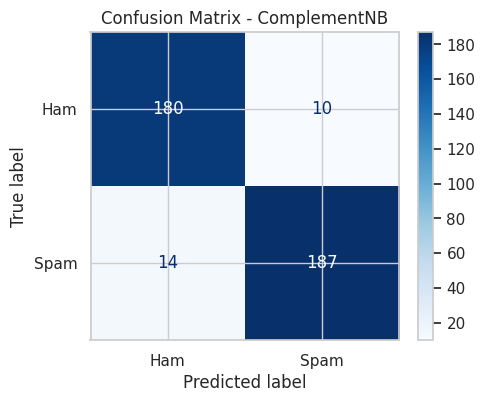

In [20]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=['Ham', 'Spam'],
    cmap='Blues',
    ax=ax,
)
ax.set_title(f'Confusion Matrix - {best_model_name}')
plt.show()


## 7. Prédictions sur nouveaux commentaires


In [21]:
examples = [
    'This song is amazing, I love it!',
    'Win money now!!! Click here: http://spam-link.com',
    'Great tutorial, thanks for sharing.',
    'Subscribe to my channel and get free gifts!'
]

preds = best_model.predict(examples)

pd.DataFrame({
    'comment': examples,
    'prediction_label': ['Spam' if p == 1 else 'Ham' for p in preds],
    'prediction_class': preds,
})


,comment,prediction_label,prediction_class
0,"This song is amazing, I love it!",Ham,0
1,Win money now!!! Click here: http://spam-link.com,Spam,1
2,"Great tutorial, thanks for sharing.",Spam,1
3,Subscribe to my channel and get free gifts!,Spam,1


## 8. Sauvegarde du modèle


In [22]:
artifacts_dir = Path('artifacts')
artifacts_dir.mkdir(exist_ok=True)

model_path = artifacts_dir / 'spam_model_from_notebook.joblib'
joblib.dump(best_model, model_path)

print(f'Modèle sauvegardé: {model_path}')


Modèle sauvegardé: artifacts/spam_model_from_notebook.joblib
